In [4]:
#easter egg :p
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
spy = yf.download("SPY", start="1993-01-01")


prices = spy["Close"]
daily_returns = prices.pct_change()


#cumprod returns cumulative_product
#always vectorize

cumulative_returns = (1 + daily_returns).cumprod() - 1
    #  (100% + x).cumprod()


#spy.head()
daily_returns.head()
cumulative_returns.head()

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
1993-01-29,NaN
1993-02-01,0.007111
1993-02-02,0.009246
1993-02-03,0.019914
1993-02-04,0.024182


In [6]:
rolling_peak = prices.cummax()
drawdown = prices / rolling_peak - 1
drawdown.head()
print(drawdown.min())

equity_curve = (1 + daily_returns).cumprod() 

Ticker
SPY   -0.551894
dtype: float64


<Figure size 1200x600 with 0 Axes>

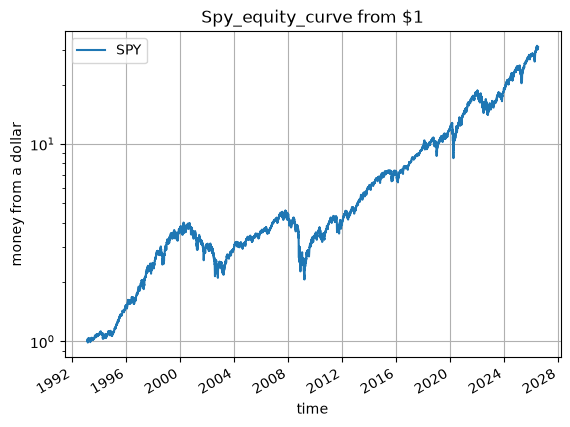

In [7]:
plt.figure(figsize = (12,6))
equity_curve.plot(label = "spy equity curve")
plt.title("Spy_equity_curve from $1")
plt.xlabel("time")
plt.ylabel("money from a dollar")
plt.grid(True)
plt.yscale("log")
plt.legend()

<Axes: xlabel='Date'>

<Figure size 640x480 with 0 Axes>

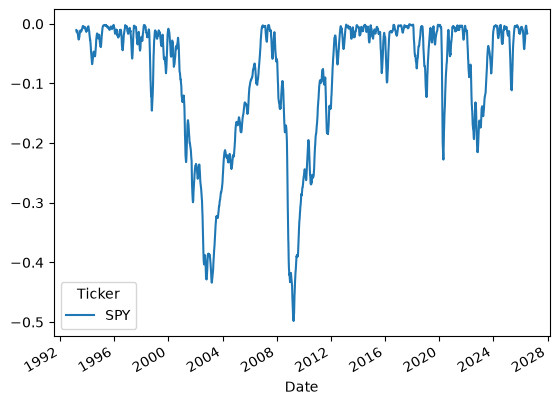

In [8]:
# plt.figure()
# drawdown.plot(label = "drawdown")
# plt.title("Drawdown Plot")
# plt.xlabel("time")
# plt.ylabel("curr drop from max")
# plt.grid(True)
# plt.legend()

#interesting plot: to make smooth, using rolling(window = x)


smoothed_drawdown = drawdown.rolling(window=30).mean()

plt.figure()
smoothed_drawdown.plot(label = "smoothed_darwodnw0")

In [9]:
total_return = equity_curve.iloc[-1]

years = len(daily_returns.dropna()) / 252

cagr = total_return ** (1 / years) - 1


#standard deviation of yearly returns
annualized_volatility = np.sqrt(252) * daily_returns.std()

sharpe_ratio = daily_returns.mean() / daily_returns.std() * np.sqrt(252)

max_drawdown = drawdown.min()

In [10]:
summary_stats = pd.Series({
    "CAGR": cagr,
    "Annualized Volatility": annualized_volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Max Drawdown": max_drawdown
})

summary_stats

CAGR                     Ticker
SPY    0.108345
Name: 2026-06-30 00:00:...
Annualized Volatility                Ticker
SPY    0.185753
dtype: float64
Sharpe Ratio                         Ticker
SPY    0.646821
dtype: float64
Max Drawdown                         Ticker
SPY   -0.551894
dtype: float64
dtype: object

In [11]:
depth = -0.05
length = 21 #if it goes down 5% in the last 21 days, we buy
hold = 21 #and then we hold it for 21 days

In [12]:
#there is only invested and not invested.

In [13]:
rolling_peak = prices.rolling(21).max()
rolling_drawdown = prices / rolling_peak - 1
buy_signal = rolling_drawdown <= depth #boolean list

position = buy_signal.rolling(hold).max() #1 if buy_signal is 1 in the past 'hold' days
position = position.fillna(0) #else 0

position = position.shift(1).fillna(0) #no cheating
strategy_returns = position * daily_returns
btd_equity_curve = (1 + strategy_returns).cumprod()

Text(0, 0.5, 'money change')

<Figure size 640x480 with 0 Axes>

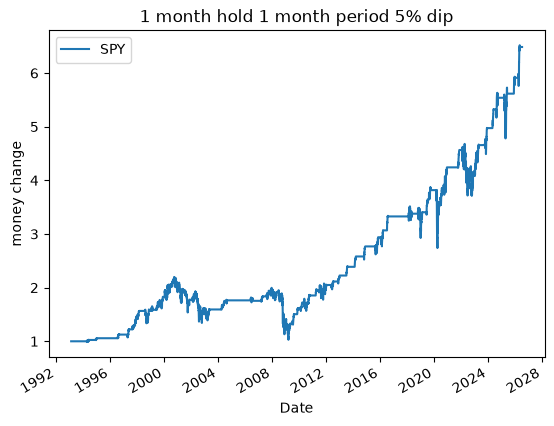

In [14]:
plt.figure()
btd_equity_curve.plot(label="SPY")
plt.title("1 month hold 1 month period 5% dip")
plt.legend()
plt.ylabel("money change")

In [15]:
#note how it's pretty bad here. that's what we expected

equity_curve = equity_curve.squeeze()
btd_equity_curve = btd_equity_curve.squeeze()

In [16]:
#comparing the two:
comparison = pd.DataFrame({
    "Buy and hold" : equity_curve,
    "BTD, 5%, month, month" : btd_equity_curve
})

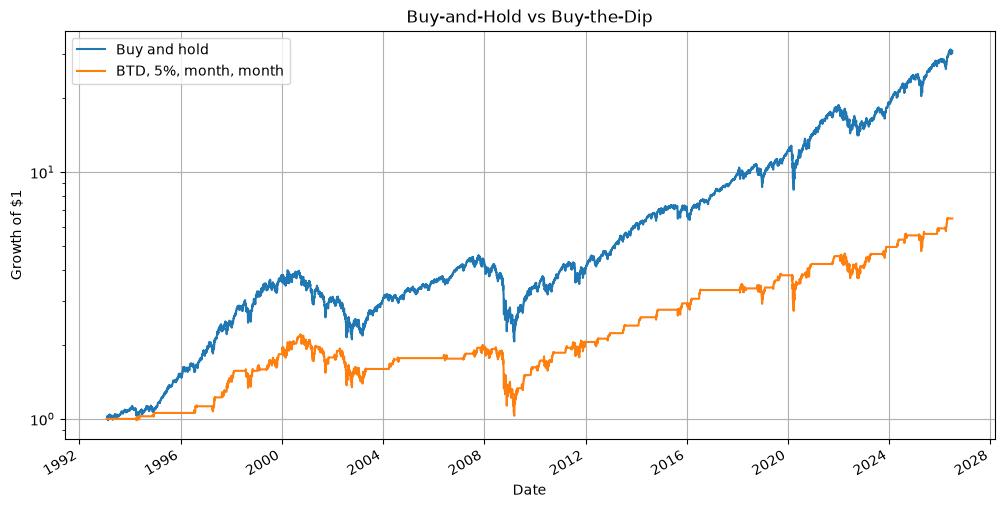

In [17]:
comparison.plot(figsize=(12, 6), logy=True)
plt.title("Buy-and-Hold vs Buy-the-Dip")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [18]:
btd_equity_curve = btd_equity_curve.squeeze()
equity_curve = equity_curve.squeeze()
daily_returns = daily_returns.squeeze()
strategy_returns = strategy_returns.squeeze()
drawdown = drawdown.squeeze()

years = len(daily_returns.dropna()) / 252

buy_hold_total_return = equity_curve.iloc[-1]
buy_hold_cagr = buy_hold_total_return ** (1 / years) - 1
buy_hold_vol = daily_returns.std() * np.sqrt(252)
buy_hold_sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
buy_hold_max_drawdown = drawdown.min()



In [19]:
btd_total_return = btd_equity_curve.iloc[-1]
btd_cagr = btd_total_return ** (1 / years) - 1
btd_vol = strategy_returns.std() * np.sqrt(252)
btd_sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)

btd_drawdown = btd_equity_curve / btd_equity_curve.cummax() - 1
btd_max_drawdown = btd_drawdown.min()


In [20]:
summary_table = pd.DataFrame({
    "Buy and Hold": [
        buy_hold_cagr,
        buy_hold_vol,
        buy_hold_sharpe,
        buy_hold_max_drawdown
    ],
    "BTD -5%, 1M lookback, 1M hold": [
        btd_cagr,
        btd_vol,
        btd_sharpe,
        btd_max_drawdown
    ]
}, index=[
    "CAGR",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
])

summary_table

,Buy and Hold,"BTD -5%, 1M lookback, 1M hold"
CAGR,0.108345,0.057617
Annualized Volatility,0.185753,0.155492
Sharpe Ratio,0.646821,0.437970
Max Drawdown,-0.551894,-0.531486


In [21]:
def run_btd_strategy(prices, daily_returns, depth, lookback=21, hold=21):
    prices = prices.squeeze()
    daily_returns = daily_returns.squeeze() #squeeze from df to series

    rolling_peak = prices.rolling(lookback).max()
    rolling_drawdown = prices / rolling_peak - 1

    buy_signal = rolling_drawdown <= depth

    position = buy_signal.rolling(hold).max()
    position = position.fillna(0)
    position = position.shift(1).fillna(0)


    strategy_returns = position * daily_returns
    strategy_returns = strategy_returns.fillna(0)

    equity_curve = (1 + strategy_returns).cumprod()

    return strategy_returns, equity_curve

    

In [22]:
btd_5_returns, btd_5_equity = run_btd_strategy(
    prices,
    daily_returns,
    depth=-0.05,
    lookback=21,
    hold=21
)

btd_10_returns, btd_10_equity = run_btd_strategy(
    prices,
    daily_returns,
    depth=-0.10,
    lookback=21,
    hold=21
)

btd_20_returns, btd_20_equity = run_btd_strategy(
    prices,
    daily_returns,
    depth=-0.20,
    lookback=21,
    hold=21
)

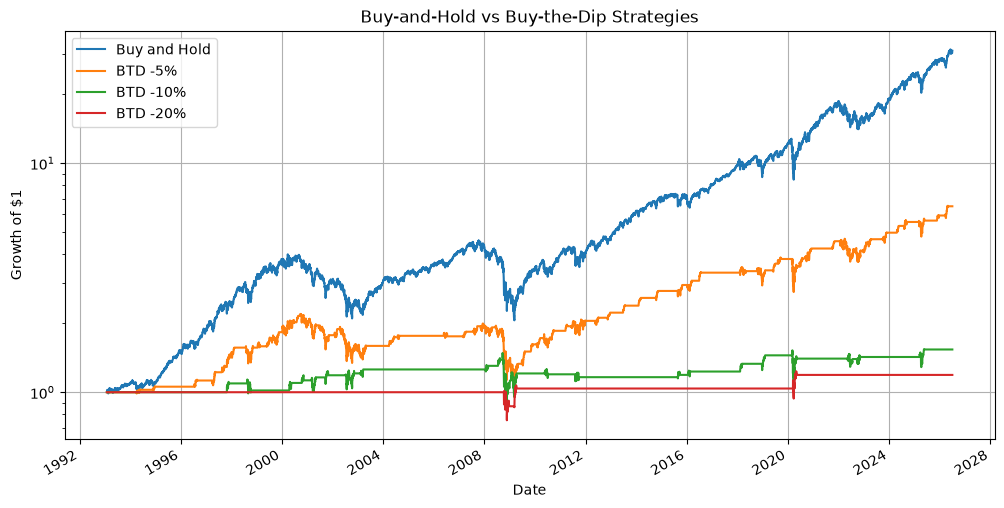

In [23]:
equity_comparison = pd.DataFrame({
    "Buy and Hold": equity_curve.squeeze(),
    "BTD -5%": btd_5_equity.squeeze(),
    "BTD -10%": btd_10_equity.squeeze(),
    "BTD -20%": btd_20_equity.squeeze()
})

equity_comparison.plot(figsize=(12, 6), logy=True)
plt.title("Buy-and-Hold vs Buy-the-Dip Strategies")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [24]:
def compute_stats(returns, equity_curve):
    returns = returns.squeeze().fillna(0)
    equity_curve = equity_curve.squeeze()

    years = len(returns) / 252

    cagr = equity_curve.iloc[-1] ** (1 / years) - 1
    vol = returns.std() * np.sqrt(252)

    if returns.std() == 0:
        sharpe = np.nan
    else:
        sharpe = returns.mean() / returns.std() * np.sqrt(252)

    drawdown = equity_curve / equity_curve.cummax() - 1
    max_drawdown = drawdown.min()

    return pd.Series({
        "CAGR": cagr,
        "Annualized Volatility": vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    })

In [25]:
depths = [-0.05, -0.10, -0.15, -0.20]

lookbacks = {
    "1W": 5,
    "2W": 10,
    "3W": 15,
    "1M": 21,
    "3M": 63,
    "6M": 126,
    "1Y": 252
}

holds = {
    "1M": 21,
    "2M": 42,
    "3M": 63,
    "6M": 126,
    "1Y": 252,
    "3Y": 756,
    "5Y": 1260
}

all_returns = {}
all_equity = {}
rows = []

for depth in depths:
    for lookback_name in lookbacks:
        for hold_name in holds:
            lookback = lookbacks[lookback_name]
            hold = holds[hold_name]

            name = f"{int(abs(depth) * 100)}% depth, {lookback_name} lookback, {hold_name} hold"

            rets, eq = run_btd_strategy(
                prices,
                daily_returns,
                depth=depth,
                lookback=lookback,
                hold=hold
            )

            all_returns[name] = rets
            all_equity[name] = eq

            stats = compute_stats(rets, eq)
            stats["Depth"] = depth
            stats["Lookback"] = lookback_name
            stats["Hold"] = hold_name
            stats["Strategy"] = name

            rows.append(stats)

results = pd.DataFrame(rows)
returns_df = pd.DataFrame(all_returns)
equity_df = pd.DataFrame(all_equity)

In [26]:
len(results)

196

In [27]:
results["Sharpe Ratio"].isna().sum()

np.int64(7)

In [28]:
stats

CAGR                                            0.064586
Annualized Volatility                           0.153204
Sharpe Ratio                                    0.485067
Max Drawdown                                   -0.496864
Depth                                               -0.2
Lookback                                              1Y
Hold                                                  5Y
Strategy                 20% depth, 1Y lookback, 5Y hold
dtype: object

In [29]:
rows

[CAGR                                           0.029441
 Annualized Volatility                           0.13211
 Sharpe Ratio                                   0.285553
 Max Drawdown                                   -0.40532
 Depth                                             -0.05
 Lookback                                             1W
 Hold                                                 1M
 Strategy                 5% depth, 1W lookback, 1M hold
 dtype: object,
 CAGR                                           0.043498
 Annualized Volatility                          0.142385
 Sharpe Ratio                                   0.370105
 Max Drawdown                                  -0.446802
 Depth                                             -0.05
 Lookback                                             1W
 Hold                                                 2M
 Strategy                 5% depth, 1W lookback, 2M hold
 dtype: object,
 CAGR                                           0.045755

In [30]:
best_idx = results["CAGR"].idxmax()
best_strategy = results.loc[best_idx, "Strategy"]

best_strategy

'5% depth, 3M lookback, 6M hold'

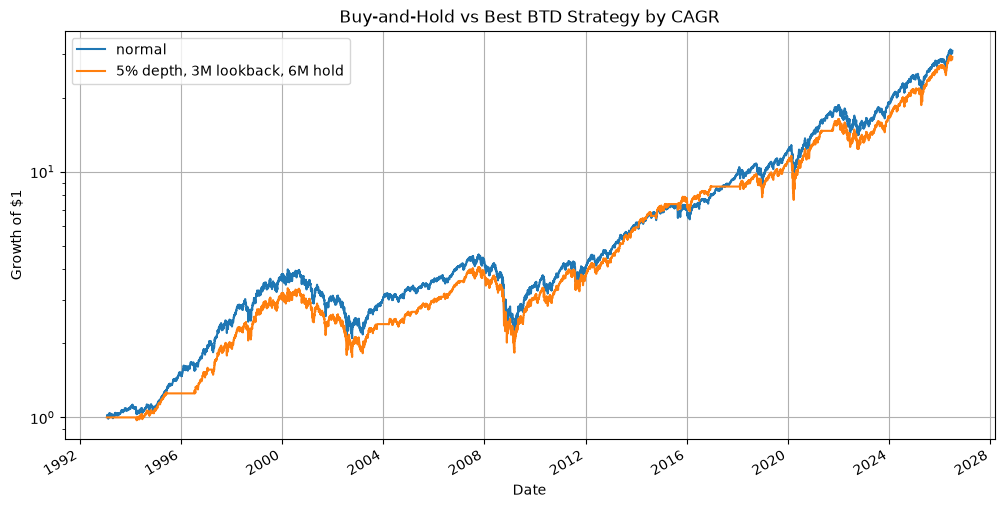

In [31]:
comparison = pd.DataFrame ({
    "normal" : equity_curve.squeeze(),
    best_strategy: equity_df[best_strategy].squeeze()
})

comparison.plot(figsize=(12, 6), logy=True)

plt.title("Buy-and-Hold vs Best BTD Strategy by CAGR")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [32]:
buy_hold_stats = compute_stats(daily_returns, equity_curve)
best_btd_stats = results.loc[best_idx]

pd.DataFrame({
    "Buy and Hold": buy_hold_stats,
    "Best BTD by CAGR": best_btd_stats[["CAGR", "Annualized Volatility", "Sharpe Ratio", "Max Drawdown"]]
})

,Buy and Hold,Best BTD by CAGR
CAGR,0.108332,0.106411
Annualized Volatility,0.185742,0.18003
Sharpe Ratio,0.646783,0.651838
Max Drawdown,-0.551894,-0.551894


In [33]:
#next section completed: analysis of t-scores, significance tests
#expect partially different results due to different sources of data

In [35]:
best_strategy

'5% depth, 3M lookback, 6M hold'

In [38]:
y = returns_df[best_strategy].squeeze()
x = daily_returns.squeeze()

data = pd.DataFrame({
    "BTD": y,
    "SPY": x
}).dropna()

#beta = cov(x,y) / var(x)
beta = data["BTD"].cov(data["SPY"]) / data["SPY"].var()

In [44]:
beta

np.float64(0.9394018739939584)

In [45]:
daily_alpha = data["BTD"].mean() - beta * data["SPY"].mean()

In [46]:
alpha = 252 * daily_alpha

In [47]:
alpha

np.float64(0.004496104939292219)